### QUESTION #0
Load the dataset and apply the same cleaning seen in class: keep only active companies, 
remove ETFs and funds. Then filter to your assigned sector. 

In [1]:
#first of all, import the needed libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import yfinance as yf

#load the csv dataset and create a copy to work on
df_raw=pd.read_csv("data/symbol_info_3-25.csv")
df=df_raw.copy()

In [2]:
#preliminary analysis on the raw dataset about columns, types of data and eventual missing values

summary=pd.DataFrame({"column":df.columns,
                      "type":df.dtypes.values,
                      "missing values": df.isna().sum().values,
                      "missing percentage": (df.isna().mean()*100).round(2).values
                      })

summary
#from the summary, it is possible to see that there are very few missing values, namely in the following variables: sector, industry and country

,column,type,missing values,missing percentage
0,symbol,object,0,0.0
1,company_name,object,0,0.0
2,sector,object,2,0.2
3,industry,object,2,0.2
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


In [3]:
#DATA PREPARATION
#now it is necessary to only consider active companies, which are not ETF or funds and filter for the sector of interest (Industrials)
df_filter=df[
    (df['is_actively_trading']==True) &
    (df['is_etf']==False) &
    (df['is_fund']==False) &
    (df['market_cap']>0) &
    (df['total_revenue']>0) &
    (df['sector']=="Industrials")
].copy()


#conversion of large dollar values into billions for readibility
df_filter['market_cap_b']=df_filter['market_cap']/1e9
df_filter['enterprise_value_b']=df_filter['enterprise_value']/1e9
df_filter['total_revenue_b']=df_filter['total_revenue']/1e9
df_filter['net_income_b']=df_filter['net_income']/1e9
df_filter['free_cashflow_b']=df_filter['free_cashflow']/1e9

#convert decimal rations into percentages for readibility
df_filter["profit_margins_pct"] = df_filter["profit_margins"] * 100
df_filter["revenue_growth_pct"] = df_filter["revenue_growth"] * 100
df_filter["earnings_growth_pct"] = df_filter["earnings_growth"] * 100
df_filter["return_on_assets_pct"] = df_filter["return_on_assets"] * 100
df_filter["return_on_equity_pct"] = df_filter["return_on_equity"] * 100
df_filter["dividend_yield_pct"] = df_filter["dividend_yield"] #just to give an appropriate name to the column

#since infinite values may appear after divisions or data imports, replace them with NAs
df_filter=df_filter.replace([np.inf, -np.inf], np.nan)

#visualize the clean, filtered data
df_filter



,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,enterprise_value_b,total_revenue_b,net_income_b,free_cashflow_b,profit_margins_pct,revenue_growth_pct,earnings_growth_pct,return_on_assets_pct,return_on_equity_pct,dividend_yield_pct
40,GE,GE Aerospace,Industrials,Aerospace & Defense,217720979456,225490796544,204.130005,203.929993,212.190002,133.990005,...,225.490797,38.701998,6.647000,4.416875e+00,16.940001,14.300001,20.999999,3.271000,27.643999,0.71
53,RTX,RTX Corporation,Industrials,Aerospace & Defense,179529449472,215817093120,132.369995,134.470001,135.740005,95.269997,...,215.817093,80.738001,4.774000,5.555375e+00,5.913000,8.500000,4.900000,3.258000,8.125000,1.90
65,CAT,"Caterpillar, Inc.",Industrials,Farm & Heavy Construction Machinery,160704643072,193329020928,335.779999,336.250000,418.500000,307.049988,...,193.329021,64.809001,10.791999,5.219875e+00,16.652000,-5.000000,9.600000,9.675000,55.326998,1.68
76,UNP,Union Pacific Corporation,Industrials,Railroads,141880508416,172757499904,233.880005,234.789993,258.070007,218.550003,...,172.757500,24.249999,6.747000,4.622875e+00,27.823001,-0.600000,7.800000,9.055001,42.596999,2.28
78,HON,Honeywell International Inc.,Industrials,Conglomerates,137061277696,158374887424,210.119995,210.889999,242.770004,189.750000,...,158.374887,38.498001,5.705000,4.256000e+00,14.819001,6.900000,2.800000,7.499000,32.244998,2.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,JBTM,JBT Marel Corporation,Industrials,Specialty Industrial Machinery,6515645440,6498900992,124.129997,125.589996,139.050003,82.639999,...,6.498901,1.716000,0.084600,1.995750e-01,4.977000,5.200000,0.000000,3.641000,5.578000,0.32
988,LPX,Louisiana-Pacific Corporation,Industrials,Building Products & Equipment,6509240832,6501851648,92.720001,93.400002,122.870003,71.389999,...,6.501852,2.941000,0.420000,3.670000e-01,14.281000,3.300000,2.600000,13.334000,26.021999,1.20
989,ALK,"Alaska Air Group, Inc.",Industrials,Airlines,6504693760,10420219904,52.830002,52.849998,78.080002,32.619999,...,10.420220,11.735000,0.395000,1.000875e+00,3.366000,38.400000,0.000000,3.232000,9.311000,0.00
990,AAON,"AAON, Inc.",Industrials,Building Products & Equipment,6499224576,6517597696,79.650002,79.419998,144.070007,69.519997,...,6.517598,1.200635,0.168559,1.844674e+10,14.038999,16.800000,-68.599999,12.447000,21.613000,0.50


### QUESTION #1

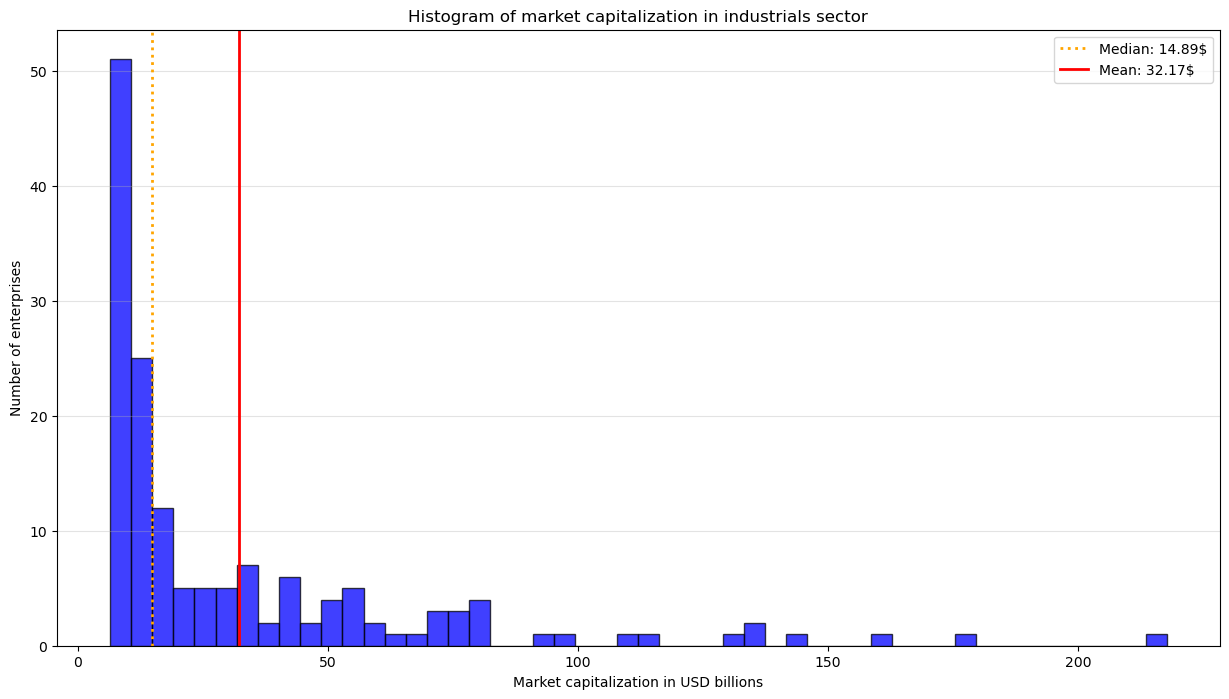

In [4]:
#filter for the only column needed (market_cap_b)
market_cap_b=df_filter["market_cap_b"]

#create the image to work on
fig,ax=plt.subplots(figsize=(15,8))

#create an histogram of the variable with 50 bins
ax.hist(market_cap_b,bins=50,color="blue",edgecolor="black",alpha=0.75)

#compute the median and mean
median=market_cap_b.median()
mean=market_cap_b.mean()

#draw the lines for the median and mean on the graph and annotate in a legend their value
ax.axvline(median, linewidth=2, color="orange", linestyle=":", label=f"Median: {median:.2f}$")
ax.axvline(mean,linewidth=2, color="red", linestyle="-", label=f"Mean: {mean:.2f}$")

#give a title to the graph
ax.set_title("Histogram of market capitalization in industrials sector")
#give a title to the x and y axis
ax.set_xlabel("Market capitalization in USD billions")
ax.set_ylabel("Number of enterprises")
#draw on horizontal grid to better show differences in the bins
plt.grid(axis='y',alpha=0.35)
#plot the legend
ax.legend()




#from the graph below it is possible to see that the distribution of market_cap_b in the industrials' sector is heavily skewed to the right. 
#This instance is also confirmed by the fact that the mean is fairly higher than the median: this practically implies that the majority of 
#companies is concentrated towards lower values of market capitalization; however, there are fewer enterprises which have much higher values
#for market capitalization, that push the mean towards a higher value.

### QUESTION #2 

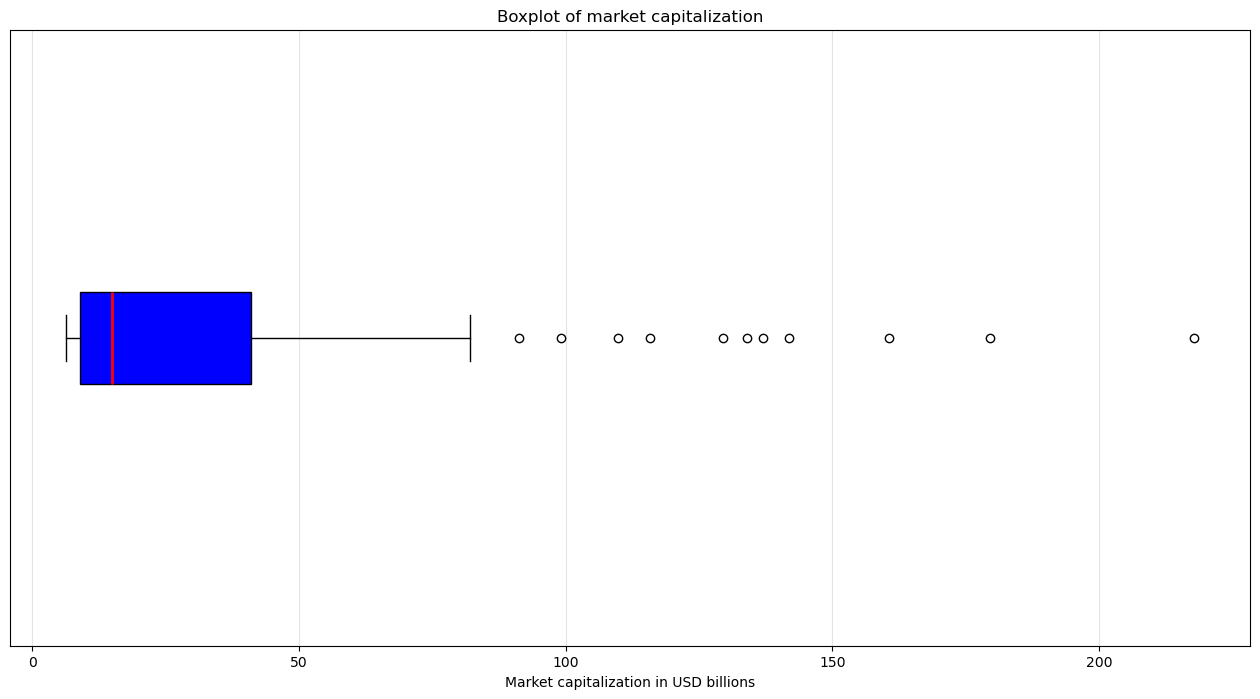

In [5]:
#plot a boxplot of market_cap
fig,ax=plt.subplots(figsize=(16,8))
ax.boxplot(market_cap_b,vert=False,patch_artist=True,
           boxprops={"facecolor":"blue","edgecolor":"black"},
           medianprops={"color":"red","linewidth":2},
           whiskerprops={"color":"black"},capprops={"color":"black"})

#give a title to the graph
ax.set_title("Boxplot of market capitalization")
ax.set_xlabel("Market capitalization in USD billions")
plt.yticks([])
#add a vertical grid for enhanced readibility
ax.grid(axis='x',alpha=0.35)


#This graph also confirmed what stated in the cell above, about the distribution of market_cap_b. The distribution appears to be heavily skewed 
#to the right, with a median that tends to lower values and a heavy tail on the right. The right tail is also characterized by the presence of 
#outliers, which will be removed in the following step.

In [15]:
#since the boxplot showed the presence of right-tail outliers, it is needed to remove them

#let's start by computing the quartiles
Q1=np.percentile(market_cap_b,25)
Q3=np.percentile(market_cap_b,75)

#compute the IQR
IQR=Q3-Q1

#bounds to identify the outliers (only upper bound needed because there are no lower outliers)
upper=Q3+1.5*IQR

#outliers removal from market_cap
market_cap_clean=market_cap_b[market_cap_b<=upper]

#outliers removal from the entire dataframe
df_clean=df_filter[(df_filter["market_cap_b"]<=upper)]



### QUESTION #3

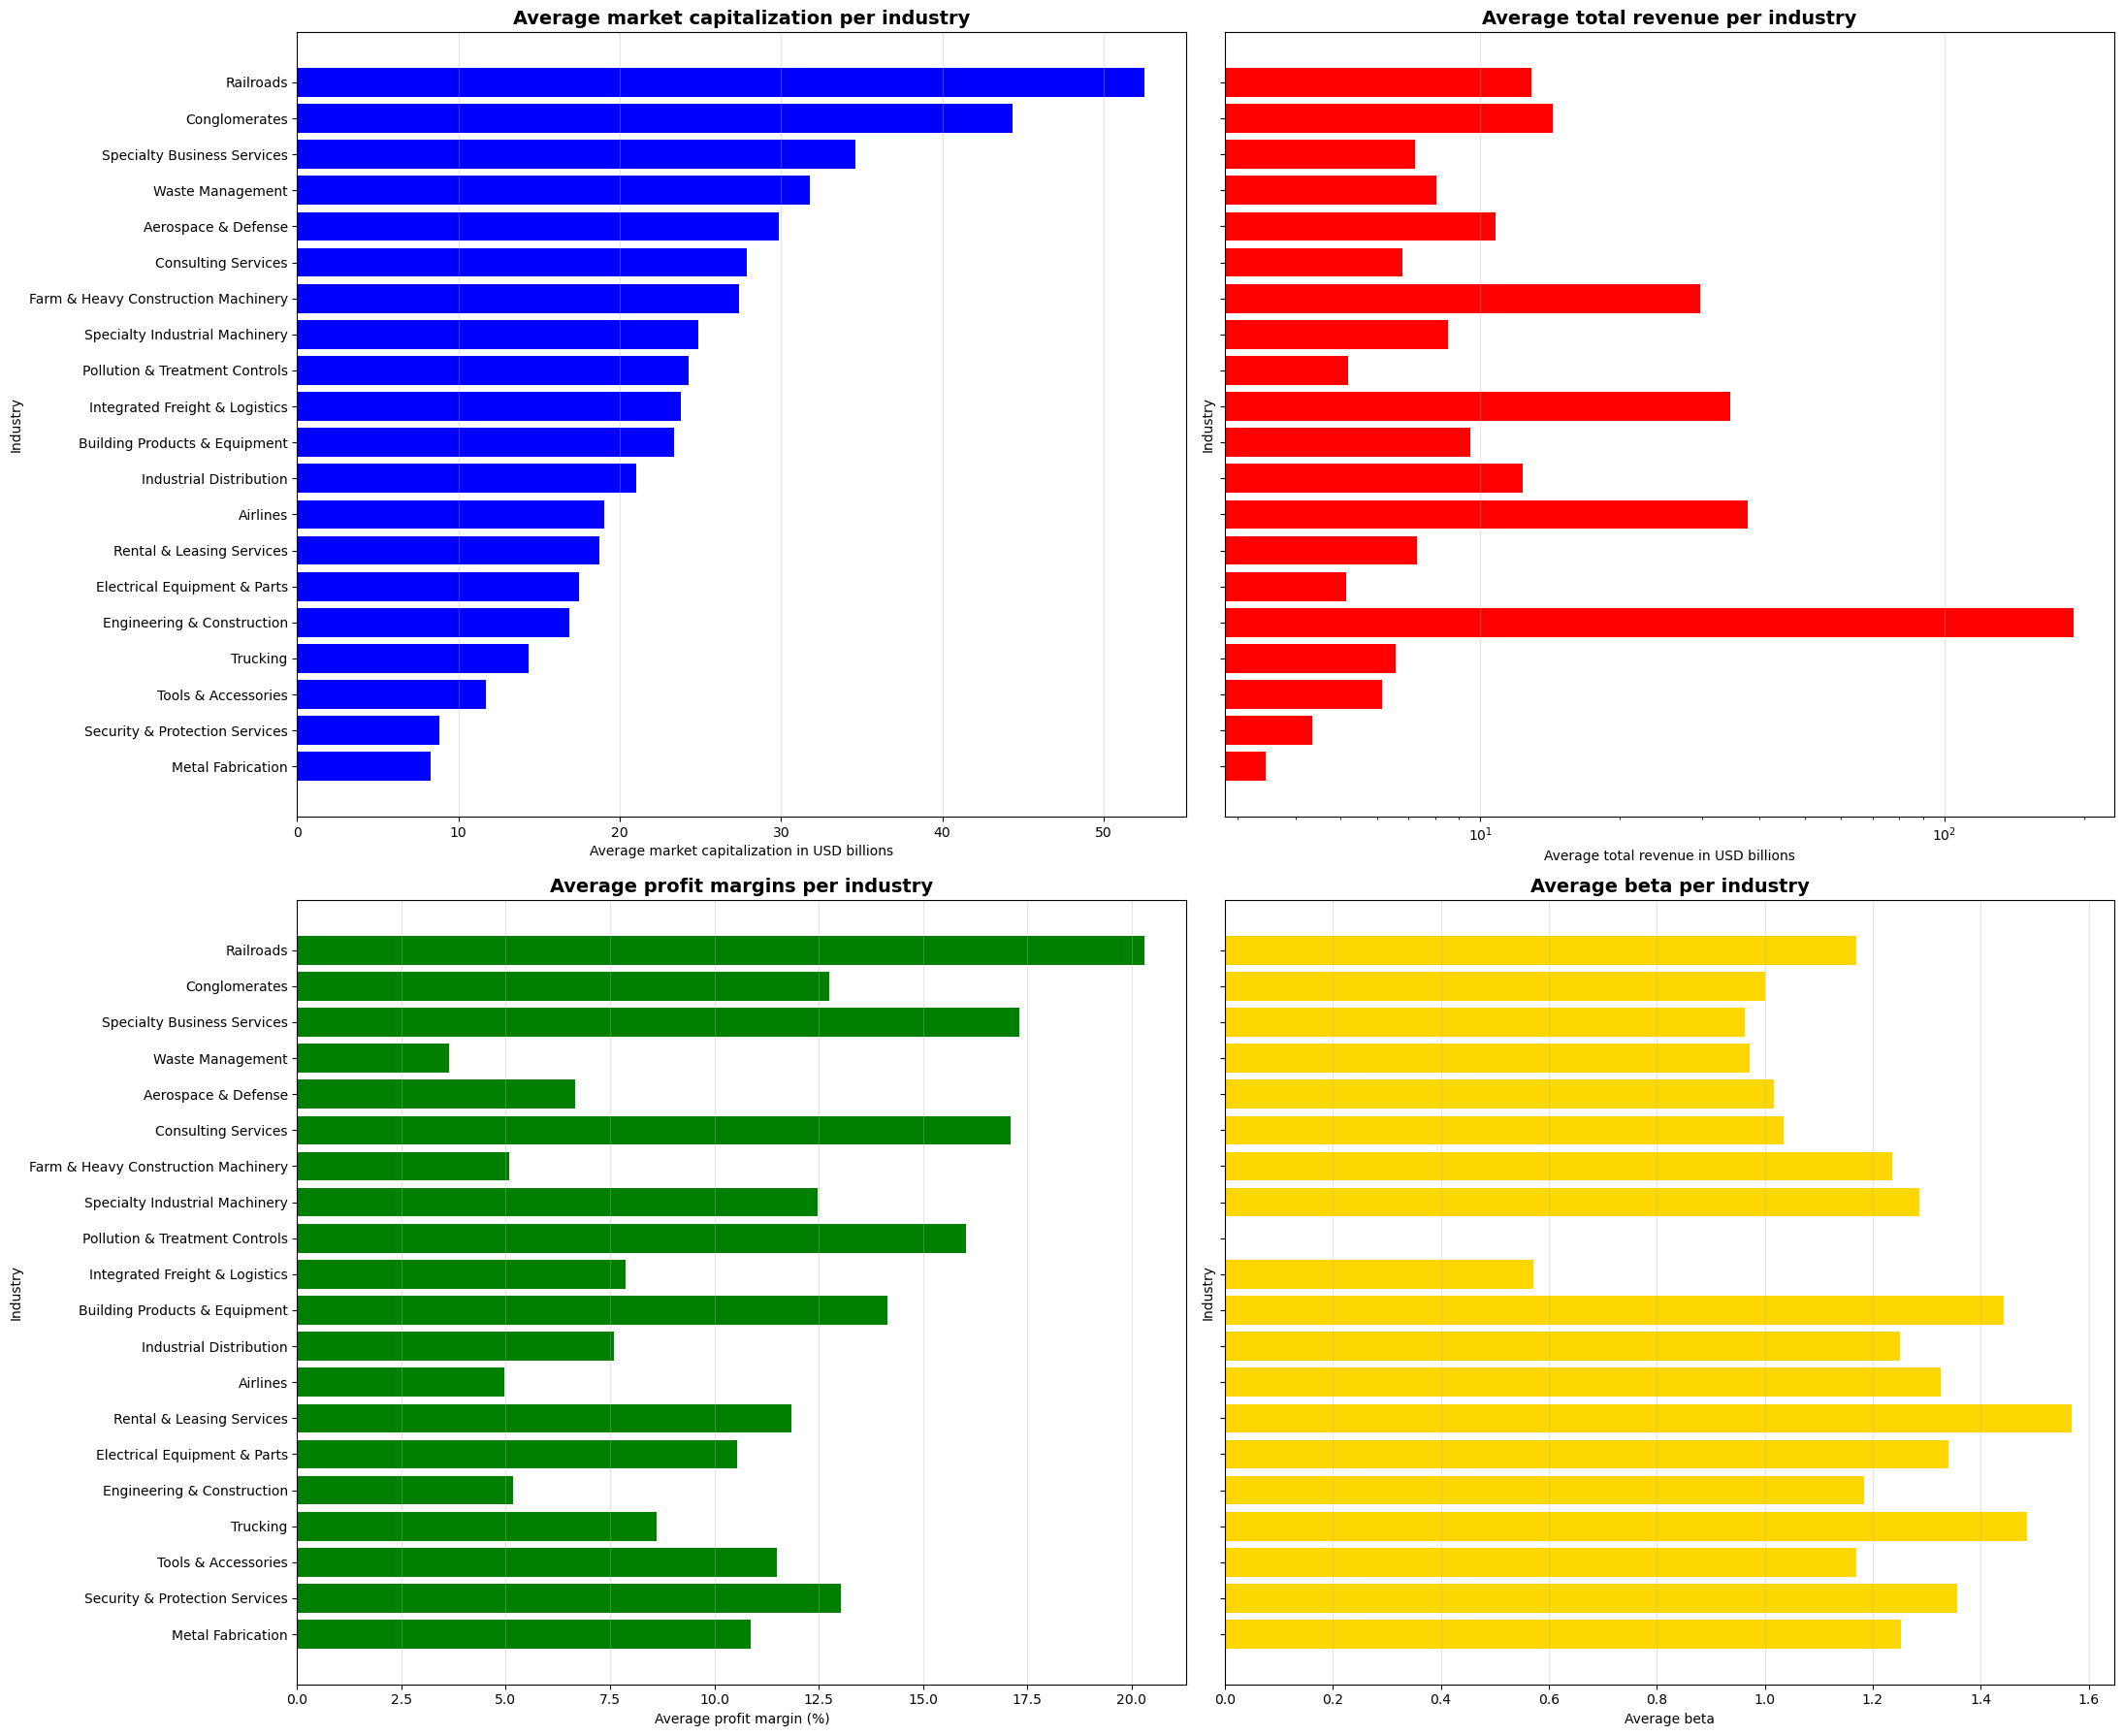

In [16]:
#grouping by industry
df_industry=df_clean.copy()
df_industry["industry_clean"]=df_industry["industry"].fillna("Unknown")

#creating a summary of the grouped dataset, where the mean for each metrics is computed
industry_summary=(df_industry).groupby("industry_clean").agg(
    mean_market_cap_b=("market_cap_b","mean"),
    mean_total_revenue_b=("total_revenue_b","mean"),
    mean_profit_margins_pct=("profit_margins_pct","mean"),
    mean_beta=("beta","mean")
)

#give an order to the industries in the graph by market_cap_b
#I chose to give to every barplot the same order by market_cap_b to simplify readibility and confrontations among different industries
industry_summary=industry_summary.sort_values("mean_market_cap_b")


#plot the barplots
fig,axes= plt.subplots(nrows=2,ncols=2,figsize=(22,18),sharey=True)

#subplot 1
axes[0,0].barh(industry_summary.index,industry_summary["mean_market_cap_b"],color="blue")
#adding vertical grids for enhanced readibility
axes[0,0].grid(axis='x',alpha=0.35)
#setting the title of this subplot and its axes
axes[0,0].set_title("Average market capitalization per industry",fontsize=14,fontweight="bold")
axes[0,0].set_xlabel("Average market capitalization in USD billions")
axes[0,0].set_ylabel("Industry")


#subplot 2
axes[0,1].barh(industry_summary.index,industry_summary["mean_total_revenue_b"], color="red")
#since in total_revenue_b the whole barplot was compressed by one big value, I decided to use the log scale to 
#better represent it
axes[0,1].set_xscale('log')
axes[0,1].grid(axis='x',alpha=0.35)
axes[0,1].set_title("Average total revenue per industry",fontsize=14,fontweight="bold")
axes[0,1].set_xlabel("Average total revenue in USD billions")
axes[0,1].set_ylabel("Industry")


#subplot 3
axes[1,0].barh(industry_summary.index,industry_summary["mean_profit_margins_pct"],color="green")
axes[1,0].grid(axis='x',alpha=0.35)
axes[1,0].set_title("Average profit margins per industry",fontsize=14,fontweight="bold")
axes[1,0].set_xlabel("Average profit margin (%)")
axes[1,0].set_ylabel("Industry")



#subplot 4
axes[1,1].barh(industry_summary.index,industry_summary["mean_beta"],color="gold")
axes[1,1].grid(axis='x',alpha=0.35)
axes[1,1].set_title("Average beta per industry",fontsize=14,fontweight="bold")
axes[1,1].set_xlabel("Average beta")
axes[1,1].set_ylabel("Industry")




plt.tight_layout()
plt.show()



In [8]:
#I want to check whether for the pollution and treatment controls average beta seems to be zero or an error has occured
print(industry_summary.loc["Pollution & Treatment Controls"])

print(df_industry[df_industry["industry_clean"]=="Pollution & Treatment Controls"][["symbol","beta"]]) 
#results show that this sector has only one industry whose beta is 0, so no error has occurred

mean_market_cap_b          24.294574
mean_total_revenue_b        5.193000
mean_profit_margins_pct    16.041000
mean_beta                   0.000000
Name: Pollution & Treatment Controls, dtype: float64
    symbol  beta
424   VLTO   0.0


### QUESTION #4

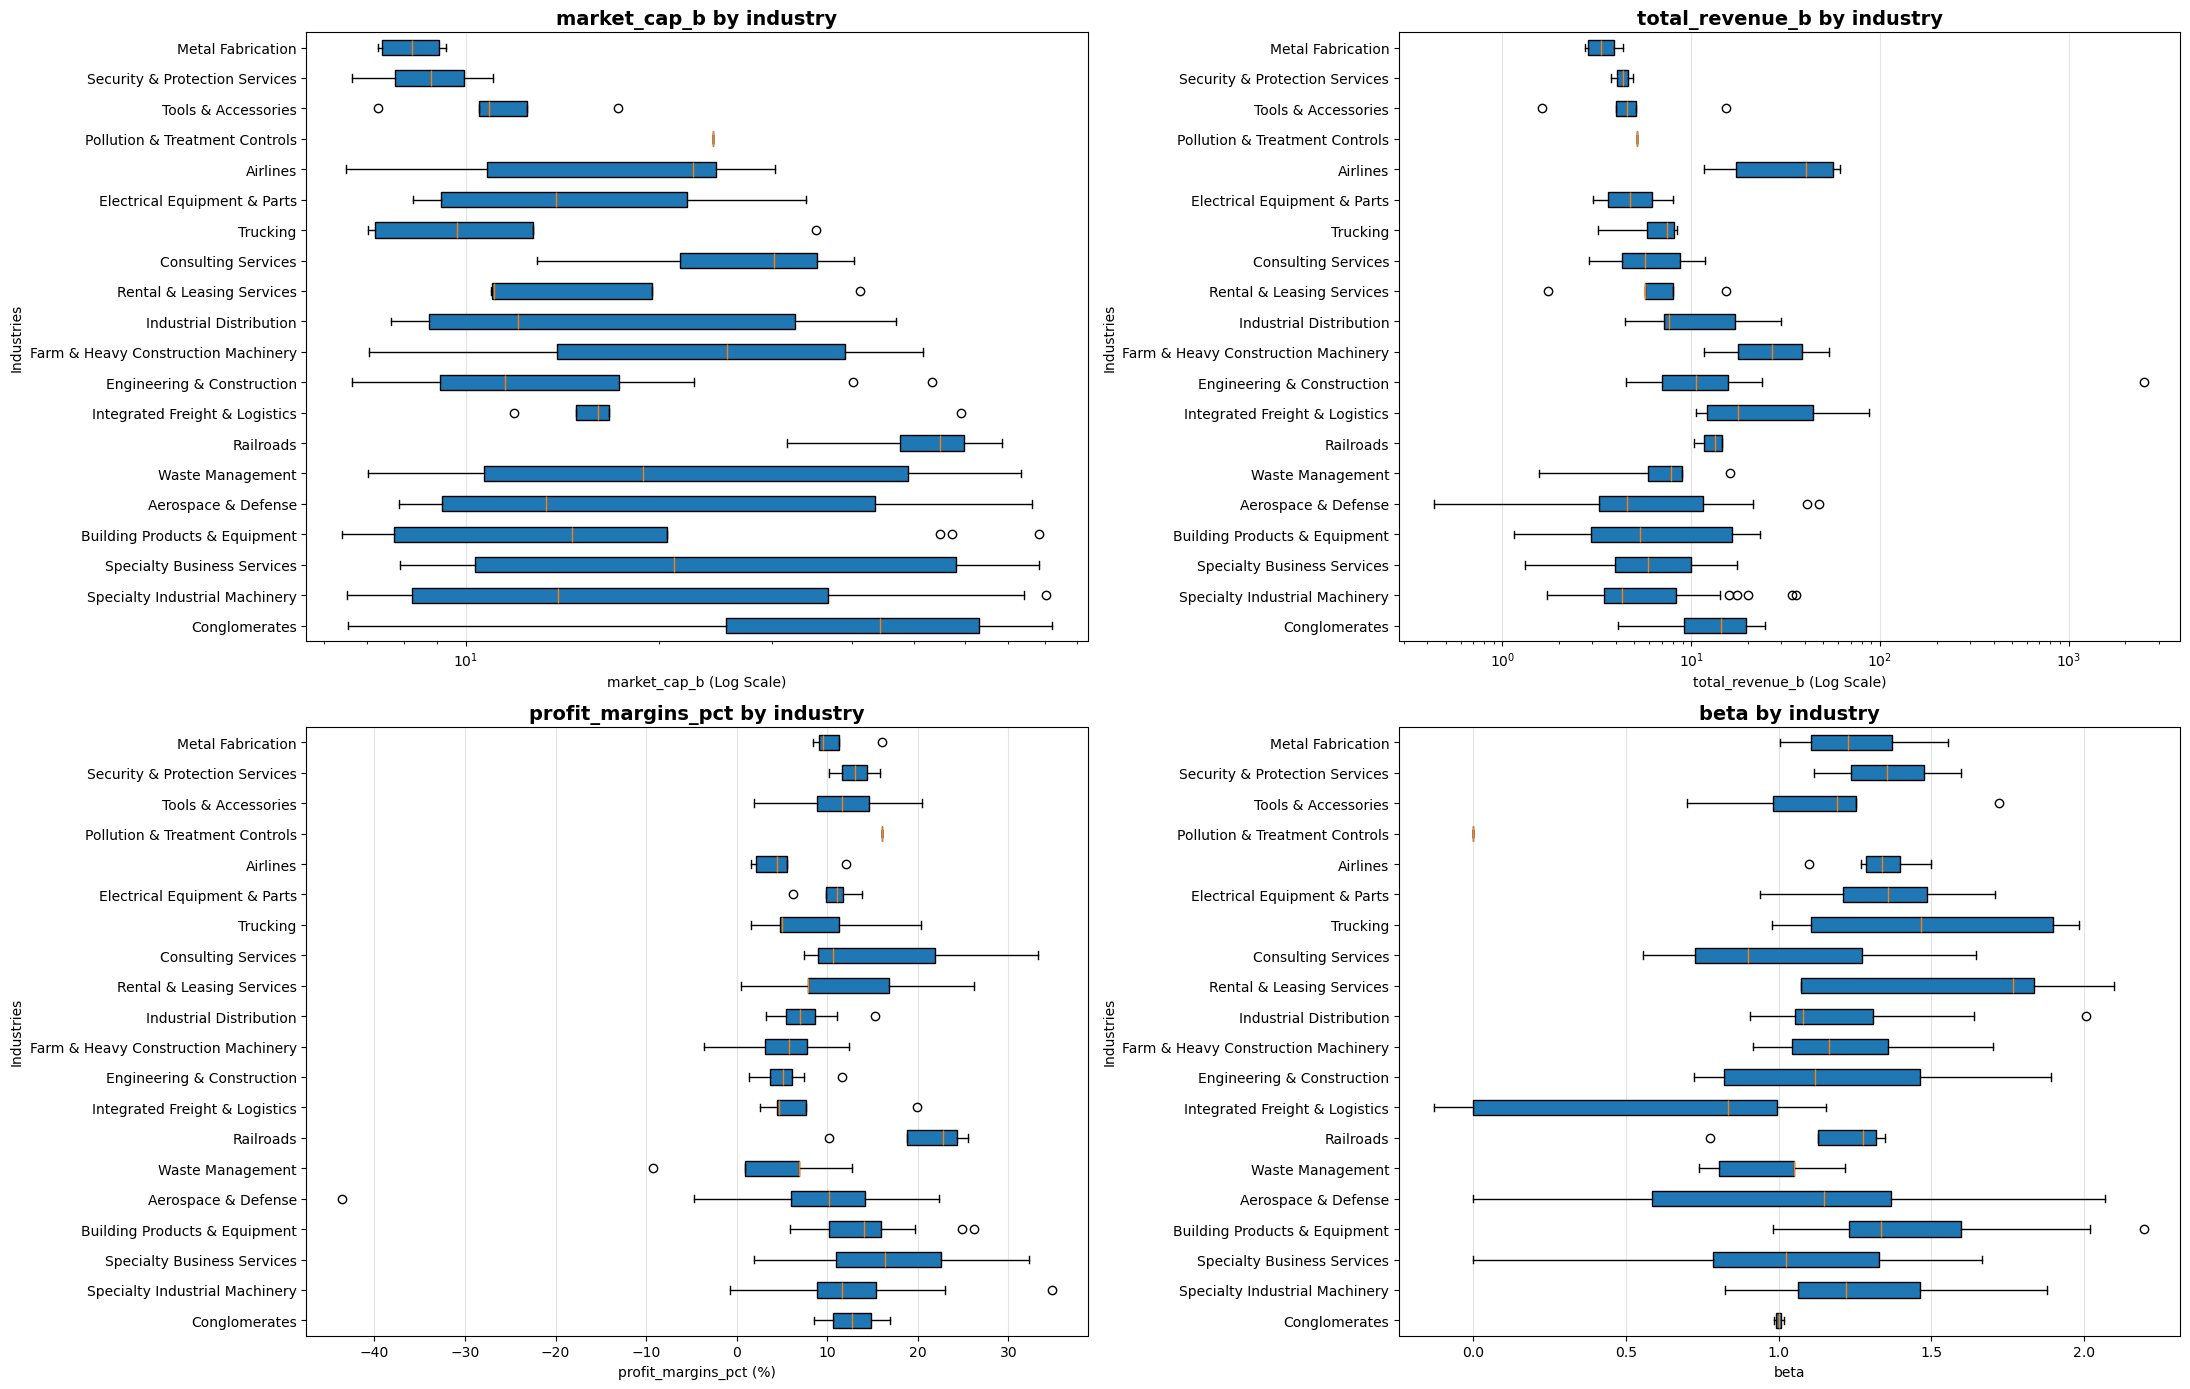

In [17]:
#select only the metrics of interest
metrics=["market_cap_b","total_revenue_b","profit_margins_pct","beta"]

#get a list of all industries without repetitions
industries=df_clean["industry"].unique()

#plot the graph
fig,axes=plt.subplots(2,2,figsize=(22,14))

#associate each axis to a metric
for ax,metric in zip(axes.flatten(),metrics):

    #for each industry keep only the metric of interest and drop eventual NA
    data=[df_clean[df_clean["industry"]==industry][metric].dropna()
    for industry in industries
    ]
    
    #create the boxplot where each label is the name of one industry
    ax.boxplot(data,tick_labels=industries,vert=False,patch_artist=True)

    #set a title for each graph
    ax.set_title(f"{metric} by industry",fontsize=14,fontweight="bold")
    
    #name the y axis where different industries appear
    ax.set_ylabel("Industries")

    #if the metric used is either market_cap_b or total_revenue_b the log scale is used, in order to improve readibility
    if metric in ["market_cap_b","total_revenue_b"]:
        ax.set_xscale("log")
        ax.set_xlabel(f"{metric} (Log Scale)") #name the x axis for the different cases
    elif metric in ["profit_margins_pct"]:
        ax.set_xlabel(f"{metric} (%)")
    else:
        ax.set_xlabel(metric)


    #add a vertical grid
    ax.grid(axis="x",alpha=0.35)

#optimize spaces among graphs to avoid overlapping
plt.tight_layout()
plt.show()



### QUESTION #5

The industries chosen to carry forward are the following:  
-Railroads: this industry was selected because it showed one of the most stable performances. It has one of the highest market capitalizations and good profit margins, while maintaining a moderate beta;  
-Conglomerates: this industry was selected because it combined large market capitalization with strong revenues and moderate beta values;  
-Specialty Business Services: this industry was selected because it shows greater variability in market capitalization and profit margins. This variability suggests an industry containing both high-performing and lower-performing firms;  
-Airlines: this industry was included because it shows a different behaviour compared to the other industries. The boxplots show high revenues combined with lower profit margins and higher beta values. These elements highlight the greater volatility of this sector.  

The remaining industries were dropped since they showed features too similar to industries already selected or less distincitve patterns in their boxplots. Dropping them allows the next analysis to better focus on contrasts among the industies selected, in terms of profitability and stability.


In [10]:
#filtering of the dataset with the chosen industries
chosen_industries=["Railroads","Conglomerates","Specialty Business Services","Airlines"]

df_focus=df_clean[df_clean["industry"].isin(chosen_industries)]
df_focus

,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,enterprise_value_b,total_revenue_b,net_income_b,free_cashflow_b,profit_margins_pct,revenue_growth_pct,earnings_growth_pct,return_on_assets_pct,return_on_equity_pct,dividend_yield_pct
139,MMM,3M Company,Industrials,Conglomerates,82124521472,87613440000,150.360001,151.270004,156.350006,85.618729,...,87.613440,24.575001,4.009000,1.678875e+00,16.981001,0.1,-21.699999,5.929000,91.850996,1.94
148,CTAS,Cintas Corporation,Industrials,Specialty Business Services,78473183232,79869763584,191.169998,194.460007,228.119995,158.097504,...,79.869764,9.940478,1.706269,1.651916e+00,17.227000,7.8,21.100000,15.268999,41.325000,0.80
154,TRI,Thomson Reuters Corp,Industrials,Specialty Business Services,76576071680,77724966912,170.009995,170.089996,180.419998,149.500000,...,77.724967,7.258000,2.190000,1.021000e+00,30.449000,5.2,-12.500000,6.361000,19.003001,1.40
178,CP,Canadian Pacific Kansas City Li,Industrials,Railroads,68701507584,91950637056,71.959999,73.580002,89.260002,70.889999,...,91.950637,14.546000,3.718000,2.329250e+00,25.560001,2.6,17.200001,4.208000,8.134000,0.73
208,CSX,CSX Corporation,Industrials,Railroads,56800714752,74208813056,29.570000,29.980000,37.400002,28.980000,...,74.208813,14.540000,3.470000,2.142000e+00,23.864999,-3.8,-14.800000,7.967000,28.336000,1.73
225,NSC,Norfolk Southern Corporation,Industrials,Railroads,52881412096,68847108096,231.750000,233.539993,277.600006,206.710007,...,68.847108,12.123000,2.619000,3.435000e-01,21.628000,-1.6,39.100000,6.883000,19.360000,2.31
230,CPRT,"Copart, Inc.",Industrials,Specialty Business Services,52024102912,48156286976,53.630001,53.849998,64.379997,48.049999,...,48.156287,4.506403,1.454344,7.006361e-01,32.272997,14.0,21.200000,12.133000,19.184999,0.00
349,WAB,Westinghouse Air Brake Technolo,Industrials,Railroads,31677022208,35191320576,184.779999,185.410004,210.880005,141.850006,...,35.191321,10.387000,1.053000,1.202500e+00,10.167000,2.3,2.000000,5.515000,10.331000,0.54
362,DAL,"Delta Air Lines, Inc.",Industrials,Airlines,30327912448,50811367424,46.770000,46.950001,69.980003,37.290001,...,50.811367,61.643002,3.457000,1.584125e+00,5.608000,9.4,-59.299999,5.046000,26.190999,1.28
420,RYAAY,Ryanair Holdings plc,Industrials,Airlines,24593113088,49869180928,46.180000,46.860001,60.316128,36.970787,...,49.869181,13.821100,1.664000,5.059375e-01,12.040000,9.7,954.300022,6.719000,20.746000,2.03


### QUESTION #6
I decided to use total revenue in USD billions on the x axis and the beta on the y axis. The size of the bubbles represents the market capitalization in USD billions and their colour represents the profit margin percentage. By combining these four encodings, the resulting chart makes it possible to identify significant patterns related to: the operational scale of a company, the risk linked with that kind of activity, the overall value of the company and its profitability.

Text(5, 0.35, 'Low revenue\nLow beta')

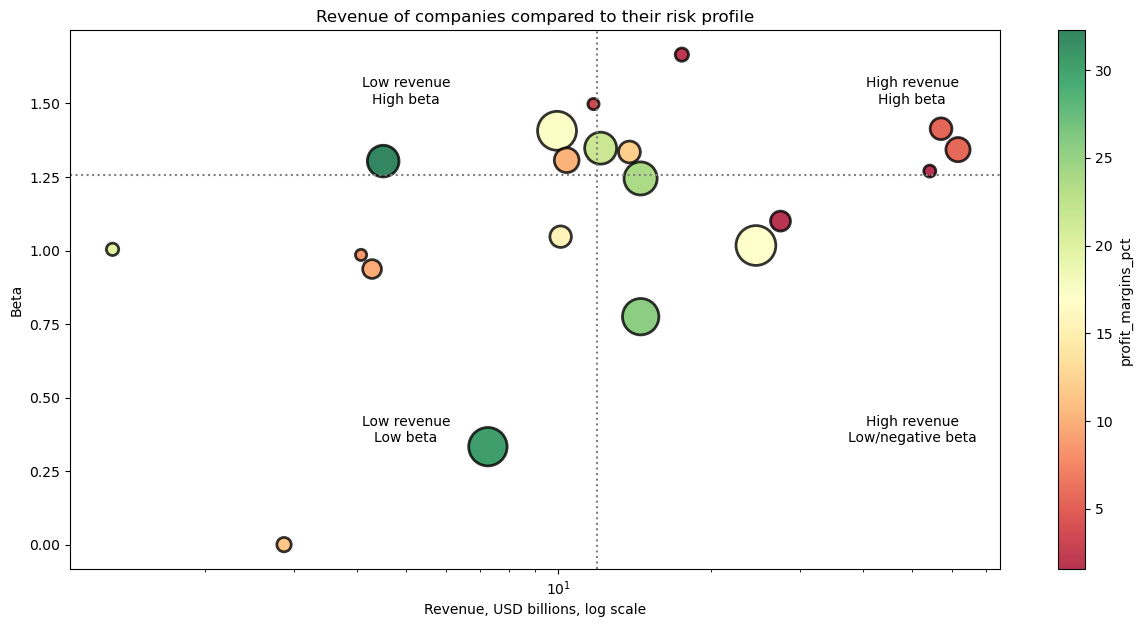

In [11]:
#create the figure
fig,ax=plt.subplots(figsize=(15,7))

#setting the dimension for the points on the graph. By taking market_cap_b, extreme values (lower than 5 or higher than 7000)
#are cut out, in order to avoid having too small or too big points. Then multiply by 10 to make the differences in size of the
#points more visible 
sizes=(df_focus["market_cap_b"].clip(lower=5,upper=7000))*10

#creating the scatterplot where on the x axis there is total_revenue_b, on the y axis the beta, the size of the bubbles represents
#the market_cap_b and their color profit_margins_pct
points=ax.scatter(df_focus["total_revenue_b"], df_focus["beta"],
                  s=sizes,c=df_focus["profit_margins_pct"],cmap="RdYlGn",
                  alpha=0.8,edgecolors="black",linewidth=2)

#setting the log scale on the x axis since total_revenue_b can vary much, in order to make the graph more readable
ax.set_xscale('log')

#in order to divide the graph into 4 quadrants, it is necessary to find the median for both x and y axis
x_med=df_focus["total_revenue_b"].median()
y_med=df_focus["beta"].median()
#draw the four quadrants
ax.axvline(x_med, linestyle=":", color="grey")
ax.axhline(y_med, linestyle=":", color="grey")

#set the title of the bubble graph
ax.set_title("Revenue of companies compared to their risk profile")
#setting the labels for x and y axis
ax.set_xlabel("Revenue, USD billions, log scale")
ax.set_ylabel("Beta")
#adding the bar on the right as a legend for the variable profit_margins_pct
bar=plt.colorbar(points,ax=ax)
bar.set_label("profit_margins_pct")

#adding a label for each quadrant with the combination of variables that it represents
ax.text(50, 1.5, "High revenue\nHigh beta", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(50, 0.35, "High revenue\nLow/negative beta", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(5, 1.5, "Low revenue\nHigh beta", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(5, 0.35, "Low revenue\nLow beta", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

### QUESTION #7

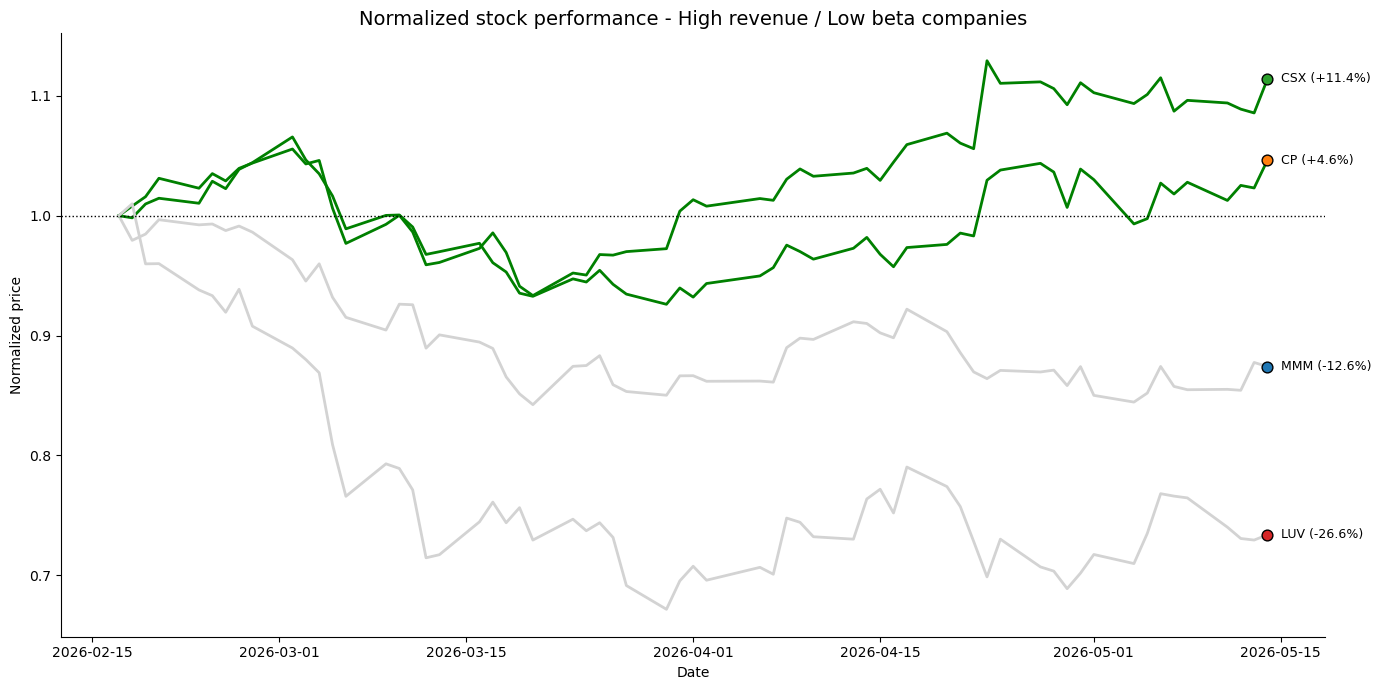

In [12]:
#choosing the quadrant of interest (high revenue and low beta) and filter for the companies in that quadrant
df_quadrant=df_focus[(df_focus["total_revenue_b"]>=x_med) & (df_focus["beta"]<=y_med)].copy()


#take the ticker for each company and convert it into a list
tickers=df_quadrant["symbol"].tolist()

#download financial data from yfinance
data=yf.download(tickers,period="3mo",interval="1d",auto_adjust=True,progress=False)
#only extract the closing prices
closing_prices=data['Close']

#normalization of the prices
normalized_prices=closing_prices/closing_prices.iloc[0]

#create the figure
fig,ax=plt.subplots(figsize=(14,7))

#iteration to make for every company
for ticker in tickers:

    #find the final date and the normalized final value of the stock
    final_date=normalized_prices.index[-1]
    final_value=normalized_prices[ticker].iloc[-1]

    #compute the return in percentage, create a label for the return and color it based on the performance (green if positive, grey if negative)
    pct=(final_value-1)*100
    label_text=f"{ticker} ({pct:+.1f}%)"
    color="green" if pct>=0 else "lightgrey"

    #plot the curve (time on the x axis and normalized price on the y axis) and label it
    ax.plot(normalized_prices.index,normalized_prices[ticker],linewidth=2,label=ticker,color=color)

    #highlight the final point of the series
    ax.scatter(final_date,final_value,s=60,edgecolor='black',zorder=5)

    #add a label with the ticker at the end of the curve
    ax.annotate(label_text,xy=(final_date,final_value),xytext=(10,0),textcoords="offset points",va="center",fontsize=9)

#adding a baseline for the starting value (=1)
ax.axhline(1,color='black',linestyle=':',linewidth=1)
#setting the title
ax.set_title("Normalized stock performance - High revenue / Low beta companies", fontsize=14)
#setting the names of the x and y axis
ax.set_xlabel("Date")
ax.set_ylabel("Normalized price")
#clearing the graph from the spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()



As it is possible to notice from the graph above, the companies of this quadrant ("high revenue/low beta") were visibly yet unevenly affected by the Hormuz crisis. 
LUV shows the most dramatic drop (-27.1%) as the growth of oil prices hit airlines companies the hardest.
MMM experiences a more gradual decline (-12.2%). This decline probably reflects the rising logistic costs associated with manufacturing.
The other two companies, both belonging to the railroad industry, show no significant negative impact.
There is also a noticeable sign of recovery, starting from april 2026, with a clear upward trend for CSX and CP and a stable line for LUV and MMM.

### QUESTION #8

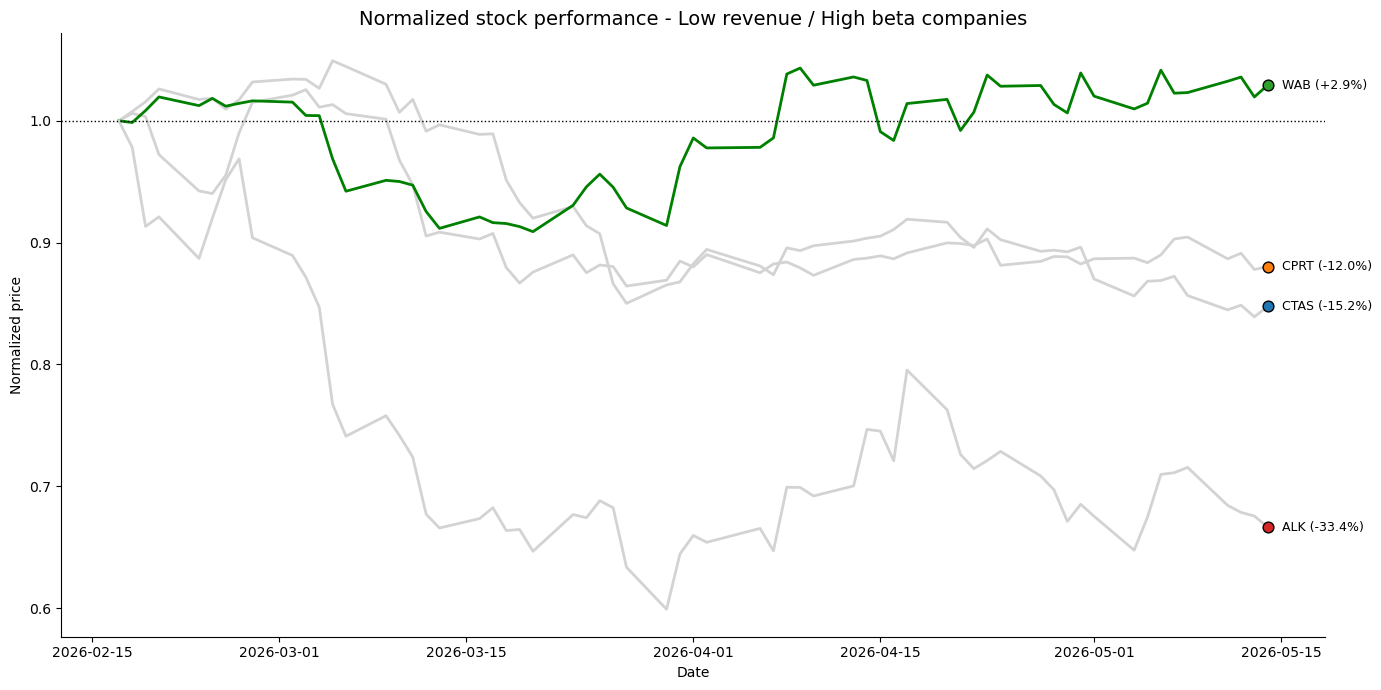

In [13]:
df_quadrant=df_focus[(df_focus["total_revenue_b"]<=x_med) & (df_focus["beta"]>=y_med)].copy()

tickers=df_quadrant["symbol"].tolist()

data=yf.download(tickers,period="3mo",interval="1d",auto_adjust=True,progress=False)
closing_prices=data['Close']

#normalization
normalized_prices=closing_prices/closing_prices.iloc[0]


fig,ax=plt.subplots(figsize=(14,7))

#iteration to make for every company
for ticker in tickers:

    #find the final date and the normalized final value of the stock
    final_date=normalized_prices.index[-1]
    final_value=normalized_prices[ticker].iloc[-1]

    #compute the return in percentage, create a label for the return and color it based on the performance (green if positive, grey if negative)
    pct=(final_value-1)*100
    label_text=f"{ticker} ({pct:+.1f}%)"
    color="green" if pct>=0 else "lightgrey"

    #plot the curve (time on the x axis and normalized price on the y axis) and label it
    ax.plot(normalized_prices.index,normalized_prices[ticker],linewidth=2,label=ticker,color=color)

    #highlight the final point of the series
    ax.scatter(final_date,final_value,s=60,edgecolor='black',zorder=5)

    #add a label with the ticker at the end of the curve
    ax.annotate(label_text,xy=(final_date,final_value),xytext=(10,0),textcoords="offset points",va="center",fontsize=9)



ax.axhline(1,color='black',linestyle=':',linewidth=1)
ax.set_title("Normalized stock performance - Low revenue / High beta companies", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Normalized price")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()



In this quadrant, representing "low revenue/high beta" enterprises, it is possible to notice a much more aggressive reaction to the closure of the Strait of Hormuz, compared to the one seen in the previous graph.
The sharpest drop is the one of ALK, an aviation company, which is to be expected as fuel costs nearly doubled.
CTAS and CPRT, tied to automotive and insurance sectors, show a strong but gradual decline, as they suffered from shipping and logistics distruptions.
On the other hand, WAB, a railroad company, showed a more stable reaction, with a slight drop, followed by a new positive tendency. 
This mirrors the resilience (already seen in the previous graph) of railroad sector: this practically shows how, as aviation and maritime shipping became progressively expensive, the market pivoted toward railroad as the most secure logistic alternative.
Unlike the previous quadrant, there is very little sign of recovery for the companies in negative.
In summary, because of their "high beta" nature, those last companies were much more affected: in fact, they show sharper drops and little sign of recovery.

### FINAL SUMMARY

The industrials sector is a quite sizeable sector, made of 154 companies, with a distribution of market capitalization which is heavily skewed to the right: this means that the majority of the companies is concentrated toward lower market capitalization values; however, there is a limited number of very large companies, which push the mean upwards. This instance is confirmed by the boxplot, which highlights the presence of some right-tail outliers. Within the industrial sector, industries show substantial differences in average market capitalization, average total revenue and average profit margins. On the other hand, the average beta per industry shows a much lower variability, although some exceptions exist: for instance, all of the industries show an average beta at least equal to 0.8, while “Integrated freight & logistics” and “Pollution & treatment control” display lower average beta values, making them less sensitive to market volatility. Overall, the industrials sector seems to be fairly profitable, in terms of market capitalization, revenue and profit margins, and at the same time relatively stable, in terms of market risk.  
The industries chosen for further analysis are: railroads, conglomerates, specialty business services and airlines. These industries were selected because they showed very different, distinguishable features in their boxplots, making them more suitable for a comparative analysis. In particular, railroads and conglomerates seem to be profitable and relatively stable sectors, with high market capitalization and contained beta values. By contrast, specialty business services displayed higher variability in market capitalization and profitability, while airlines showed higher beta values, suggesting greater volatility.  
The bubble chart provided other useful insights. Most companies were concentrated around beta values between 1 and 1.4, showing risk levels similar to or slightly higher than the market.  
The chart also highlighted important differences between quadrants: companies in "high revenue/high beta" quadrant combine high revenues with greater risk of volatility, a pattern often associated with airlines; firms in "high revenue/low beta" quadrant appear more stable despite their large size, a pattern often associated with railroads; companies within the "low revenue/high beta" quadrant tend to be smaller yet riskier; enterprises in the "low revenue/low beta" quadrant represent contained firms, with lower profitability but a relatively stable performance.  
The bubble sizes show that market capitalization is not perfectly correlated with revenue: in fact, some companies with moderate revenues still have large market values.  
Finally, color distribution suggests that companies with the highest profit margins are not always the ones with highest revenues or largest market capitalizations: this shows that the dimensions analyzed behave somehow independently across the selected industries.  
The companies chosen for the quadrant comparison generally behaved as predicted over the last three months: companies belonging to the "high revenue/low beta" quadrant, which theoretically are the most stable ones, experienced a moderate decline in February 2026, followed by a gradual recovery, starting from April of the same year. On the other hand, companies belonging to the "low revenue/high beta" quadrant displayed a much sharper decline and only little signs of recovery, reflecting their greater exposure to market volatility. This difference in behavior was consistent with the geopolitical events of the last few months, during which investors probably tended to favor larger and more stable companies, such as railroads, which appeared to be resilient in both the analyses.
